# **ITAL 1371 Mid-Term Project **

# **Ved Dalwadi Data Cleaning and Train Test spliting**

In [ ]:
#Importing all necessary tools for the dataset cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
#Styling for graph
plt.style.use('classic')
sns.set_palette("Blues")
#Import dataset from url which I put in github Url
df = pd.read_csv('https://raw.githubusercontent.com/VedD376/ITAI-1371-ML-Dataset/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
#This shows Total charges as an object. This is not ideal, as when the machine cannot learn from strings
print(df['TotalCharges'].dtype)
#We first have to fill the blank rows
blank_Rows = df[df['TotalCharges'].str.strip() == '']
print("Number of blank rows in Total Charges:", len(blank_Rows))
#This will convert into numbers and if left blank it will become NAN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors ='coerce')
#Confrim the blank rows
print(df['TotalCharges'].isnull().sum())
#Fills any missing rows with 0 as the customers with no value haven't been billed yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)
#Confrim no more missing data
print(df['TotalCharges'].isnull().sum())

object
Number of blank rows in Total Charges: 11
11
0


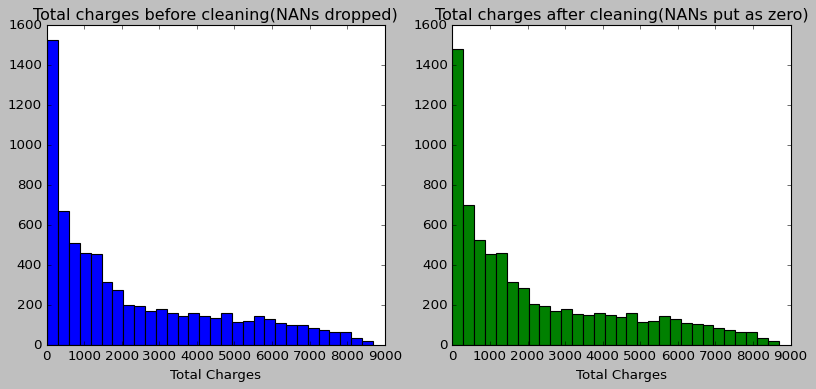

In [ ]:
#Putting the raw dataset to show before and after matlib
df_raw = pd.read_csv('https://raw.githubusercontent.com/VedD376/ITAI-1371-ML-Dataset/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')
#creates 2 plots for the before and after
fig, axes = plt.subplots(1, 2, figsize=(12,5))
before_Filling = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
#This plots the raw dataset as a histogram first
axes[0].hist(before_Filling.dropna(), bins=30, color='blue')
axes[0].set_title('Total charges before cleaning(NANs dropped)')
axes[0].set_xlabel('Total Charges')
#This first graph shows a high number of customers with a low amount billed
#This plots the raw dataset as a histogram first
axes[1].hist(df['TotalCharges'], bins=30, color='green')
axes[1].set_title('Total charges after cleaning(NANs put as zero)')
axes[1].set_xlabel('Total Charges')
plt.show()
#The before and after histograms are very similar because the number of rows changed was 11 out of 7000, which won't do much; however, this step is still important to make the machine more accurate,
#you need to do the small things that even though they may not make a huge visaul differnce it can still increase the accuarcy of the AI by some amount.
#which if this did not happen could cause problems later on in the process if this simple turing them into zeros did not occour.

In [ ]:
#We now want to drop the customer ID as this increasing number can cause the machine to focus it's attentition on the last customer more than the first when both thier data is equally as imporant
df = df.drop('customerID', axis = 1)
df.columns
#Code done by Ved Dalwadi

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#Now we want to split the data into testing and trianing sets so the AI can learn and make sure it's not just memorizing the anwsers.
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42)
#We will print each one to confrim that 70% goes to train and 30% goes to test
print("Training state", {train_df.shape})
print("test state", {test_df.shape})

Training state {(4930, 20)}
test state {(2113, 20)}


In [ ]:
#Now we want to print the before and after of the dataset cleaning
print("Before cleaning (Raw)")
print(df_raw[['customerID', 'tenure', 'TotalCharges']].head(10))
print("After cleaning (Clean)")
print(df[[ 'tenure', 'TotalCharges']].head(10))

Before cleaning (Raw)
   customerID  tenure TotalCharges
0  7590-VHVEG       1        29.85
1  5575-GNVDE      34       1889.5
2  3668-QPYBK       2       108.15
3  7795-CFOCW      45      1840.75
4  9237-HQITU       2       151.65
5  9305-CDSKC       8        820.5
6  1452-KIOVK      22       1949.4
7  6713-OKOMC      10        301.9
8  7892-POOKP      28      3046.05
9  6388-TABGU      62      3487.95
After cleaning (Clean)
   tenure  TotalCharges
0       1         29.85
1      34       1889.50
2       2        108.15
3      45       1840.75
4       2        151.65
5       8        820.50
6      22       1949.40
7      10        301.90
8      28       3046.05
9      62       3487.95


# **Monepha Mitchell EDA and Feature Engineering**

# **Nigel Bontiff - Encoding, Scaling, and Distribution Comparison**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preprocessing for the training data
train_person3 = train_df.copy()

print("Training data shape before Person 3 preprocessing:")
print(train_person3.shape)

print("\nFirst five rows before Person 3 preprocessing:")
print(train_person3.head())

Repeated Categorical Values

In [ ]:
object_columns = train_person3.select_dtypes(include=['object']).columns

for column in object_columns:
    train_person3[column] = train_person3[column].astype(str).str.strip()

service_columns = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for column in service_columns:
    if column in train_person3.columns:
        train_person3[column] = train_person3[column].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

print("Unique values after simplifying service-related columns:\n")

for column in service_columns:
    if column in train_person3.columns:
        print(column, ":", train_person3[column].unique())

Features and Target

In [ ]:
_train_person3 = train_person3.drop(columns=['Churn'])
y_train_person3 = train_person3['Churn']

# Convert Churn from Yes/No into 1/0
# Yes = customer churned
# No = customer did not churn

y_train_person3 = y_train_person3.map({
    'No': 0,
    'Yes': 1
})

print("Target value counts after converting Churn to 0 and 1:")
print(y_train_person3.value_counts())

print("\nTarget percentage distribution:")
print((y_train_person3.value_counts(normalize=True) * 100).round(2))

One-Hot Encode Categorical Columns

In [ ]:
# Find remaining categorical columns that still contain text
categorical_columns = X_train_person3.select_dtypes(include=['object']).columns

print("Categorical columns before one-hot encoding:")
print(list(categorical_columns))

# One-hot encode categorical columns
X_train_encoded = pd.get_dummies(
    X_train_person3,
    columns=categorical_columns,
    drop_first=True
)

# This section will convert True/False columns into 1/0 integers
bool_columns = X_train_encoded.select_dtypes(include=['bool']).columns
X_train_encoded[bool_columns] = X_train_encoded[bool_columns].astype(int)

print("\nTraining data shape after one-hot encoding:")
print(X_train_encoded.shape)

print("\nFirst five rows after one-hot encoding:")
print(X_train_encoded.head())

Scaling Distributions

In [ ]:
# The numeric columns I'm scaling
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Show distributions before scaling.
plt.figure(figsize=(15, 4))

for i, column in enumerate(columns_to_scale):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_train_encoded[column], bins=30)
    plt.title(f'{column} Before Scaling')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

StandardScaler Section

In [ ]:
# StandardScaler to put numeric columns on a similar scale
scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(
    X_train_scaled[columns_to_scale]
)

print("First five rows after scaling tenure, MonthlyCharges, and TotalCharges:")
print(X_train_scaled[columns_to_scale].head())

print("\nSummary statistics after scaling:")
print(X_train_scaled[columns_to_scale].describe())

After Scaling Distributions Section

In [ ]:
# display for distributions after scaling
plt.figure(figsize=(15, 4))

for i, column in enumerate(columns_to_scale):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_train_scaled[column], bins=30)
    plt.title(f'{column} After Scaling')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

Logistic Regression with Class Balancing Section

In [ ]:
# I created a validation split from the training data so the original test_df stays untouched

X = final_train_person3.drop(columns=['Churn'])
y = final_train_person3['Churn']

X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

log_reg_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_model, y_train_model)

y_pred = log_reg_model.predict(X_val_model)

print("Accuracy Score:")
print(accuracy_score(y_val_model, y_pred))

print("\nClassification Report:")
print(classification_report(y_val_model, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_model, y_pred))

# Discuss how you would use this dataset to solve a ML problem


- This preprocessing helps because the original Telco Churn dataset has a lot of text values that a machine learning model cannot use by itself. For example, columns like internet service, payment method, contract type, and other customer service features are written as words instead of numbers. By cleaning values like “No internet service” and “No phone service” into just “No,” the data becomes more consistent and easier to work with.

  After that, one-hot encoding changes the categorical columns into 0 and 1 values, which makes the data usable for a machine learning model. I also scaled the numerical columns, including tenure, MonthlyCharges, and TotalCharges, because those columns are on different ranges. Scaling helps make sure one feature does not seem more important just because it has larger numbers.

  I also used class_weight='balanced' in the Logistic Regression model because the dataset has more customers who did not churn than customers who did churn. This helps the model pay more attention to the smaller churn group instead of mainly predicting the majority class. Overall, these steps help turn the training data into a cleaner and more model-ready dataset that could be used to predict whether a customer is likely to churn.